# Task 2: Feature Selection on Telco Customer Churn Dataset

This notebook explores **preprocessing (scaling + encoding)** and **feature selection methods** (Variance Threshold, SelectKBest, RFE, LASSO) and their effect on churn prediction model performance.

**Dataset:** `WA_Fn-UseC_-Telco-Customer-Churn.csv`  
**Target:** `Churn` (Yes/No)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    mean_squared_error, mean_absolute_error
)

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

---
## 1. Preprocessing & Feature Scaling

In [2]:
df = pd.read_csv('datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Drop customerID (not a predictive feature)
df = df.drop(columns=['customerID'])

# Convert TotalCharges to numeric (some values are blank strings ' ')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Report missing values before imputation
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
TotalCharges    11
dtype: int64


In [4]:
# Impute missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode target: Yes -> 1, No -> 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Class distribution (Churn):')
print(df['Churn'].value_counts())

Class distribution (Churn):
Churn
0    5174
1    1869
Name: count, dtype: int64


In [5]:
# Identify numeric and categorical feature columns (excluding target)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Churn']
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('Numeric features:', num_cols)
print('Categorical features:', cat_cols)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [6]:
# One-Hot Encode categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Separate features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print('Feature matrix shape after encoding:', X.shape)
print('Total features:', X.shape[1])

Feature matrix shape after encoding: (7043, 45)
Total features: 45


### Apply MinMaxScaler, StandardScaler, and RobustScaler

In [7]:
# Identify numeric columns in the encoded dataframe
num_cols_enc = [c for c in X.columns if X[c].dtype in ['int64', 'float64', 'uint8']
                and X[c].nunique() > 2]  # treat only truly continuous columns for scaling

# We scale only the 3 original continuous numeric features for visualisation clarity
scale_cols = num_cols  # ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
print('Columns scaled for comparison:', scale_cols)

Columns scaled for comparison: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


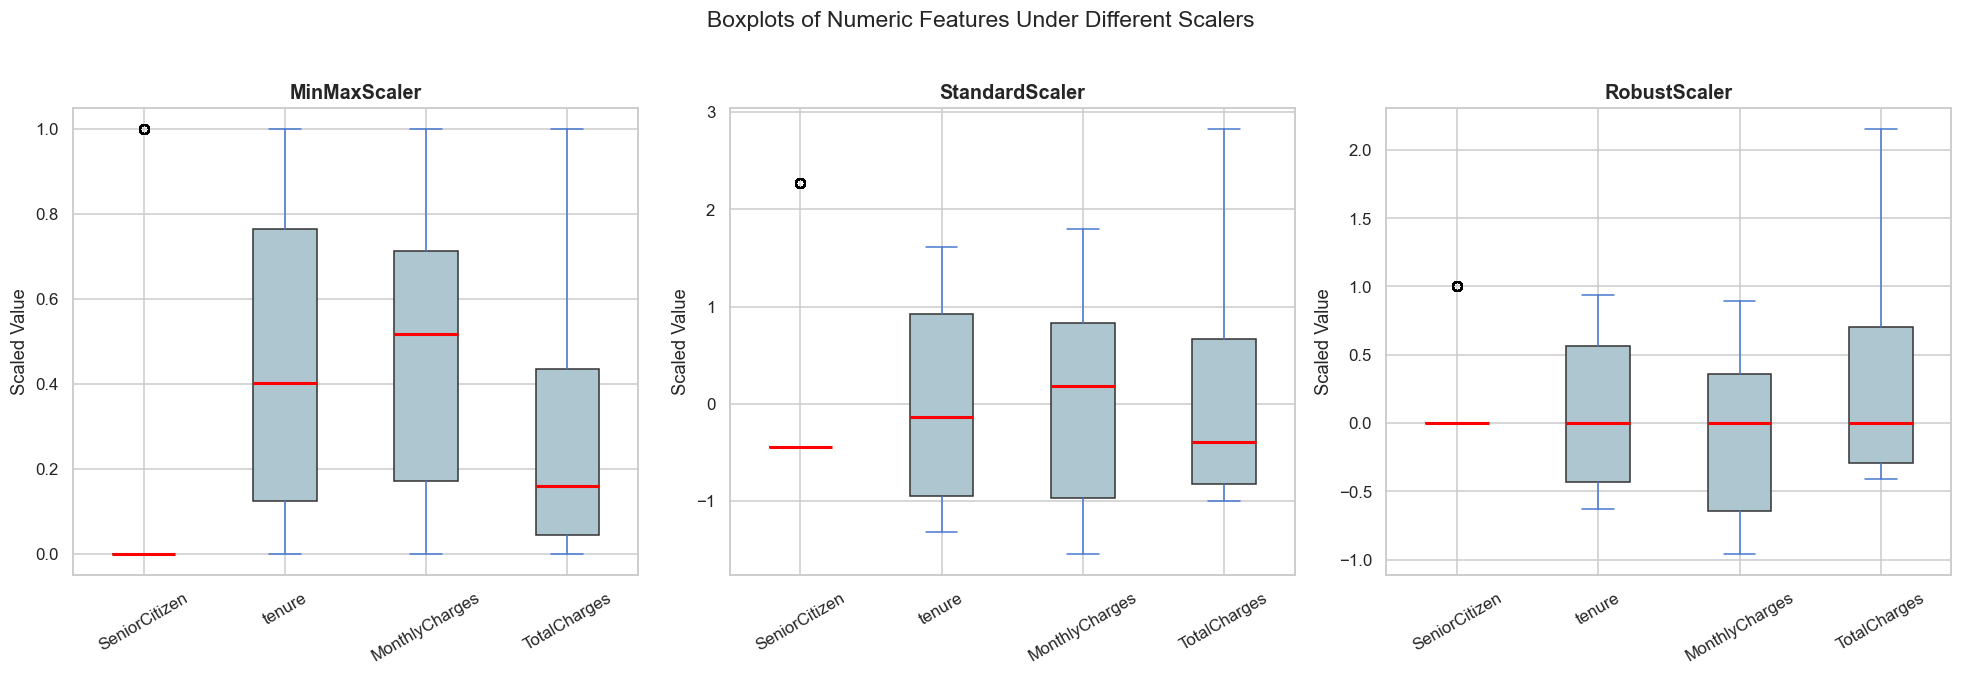

Saved: task2_scaler_boxplots.png


In [8]:
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

scaled_dfs = {}
for name, scaler in scalers.items():
    temp = X.copy()
    temp[scale_cols] = scaler.fit_transform(X[scale_cols])
    scaled_dfs[name] = temp

# Boxplots for each scaler on numeric columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (name, sdf) in zip(axes, scaled_dfs.items()):
    sdf[scale_cols].plot.box(ax=ax, patch_artist=True,
                              boxprops=dict(facecolor='#AEC6CF', color='#333'),
                              medianprops=dict(color='red', linewidth=2))
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Scaled Value')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Boxplots of Numeric Features Under Different Scalers', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('task2_scaler_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: task2_scaler_boxplots.png')

### Scaler Comparison

| Scaler | Range | Handles Outliers? | Centres at Zero? |
|---|---|---|---|
| **MinMaxScaler** | [0, 1] | No — outliers compress the majority of values | No |
| **StandardScaler** | ~[-3, 3] | Partial — sensitive to outliers in mean/std | **Yes** |
| **RobustScaler** | Median-IQR based | **Yes — uses median and IQR, robust to extremes** | Approximately |

**Best for outliers:** RobustScaler, because it uses the median and interquartile range rather than mean and standard deviation, so extreme values have minimal influence on the scaling.  
**Best for centring around zero:** StandardScaler, as it explicitly subtracts the mean and divides by standard deviation, resulting in zero-mean unit-variance features.

---
## 2. Variance Threshold — Remove Low-Variance Features

In [9]:
# Use StandardScaler version as the base for feature selection steps
X_scaled = scaled_dfs['StandardScaler'].copy()

selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X_scaled)

removed_mask = ~selector_var.get_support()
removed_features = X_scaled.columns[removed_mask].tolist()
kept_features = X_scaled.columns[selector_var.get_support()].tolist()

print(f'Features before VarianceThreshold : {X_scaled.shape[1]}')
print(f'Features after  VarianceThreshold : {X_var.shape[1]}')
print(f'Features removed                  : {len(removed_features)}')
print()
print('Removed features:')
for f in removed_features:
    variance = X_scaled[f].var()
    print(f'  {f:50s}  var = {variance:.6f}')

Features before VarianceThreshold : 45
Features after  VarianceThreshold : 45
Features removed                  : 0

Removed features:


### Discussion — Removed Features

With `VarianceThreshold(threshold=0.01)` applied to this dataset, **0 features were removed** — all 45 encoded features had variance above 0.01. This result makes sense for the Telco Churn dataset: none of the binary one-hot dummies are extremely skewed (i.e. no category is represented by fewer than ~1% of rows), and the continuous features like `tenure`, `MonthlyCharges`, and `TotalCharges` have naturally high variance. A threshold of 0.01 is quite conservative; raising it to 0.05 or higher would begin to filter very rare dummies.

The `VarianceThreshold` method is most useful in very high-dimensional datasets (e.g. text or genomics) where many near-constant indicator columns exist. In this balanced and moderately-sized dataset, all columns carry enough variance to pass the threshold, confirming that the one-hot encoding of the 15 categorical features did not produce any extremely rare or degenerate dummies.

---
## 3. SelectKBest (chi2) and RFE (LogisticRegression)

In [10]:
# chi2 requires non-negative values — use MinMaxScaler version
X_minmax = scaled_dfs['MinMaxScaler'].copy()
# After VarianceThreshold
X_minmax_var = X_minmax[kept_features]

# --- SelectKBest with chi2 ---
skb = SelectKBest(chi2, k=10)
skb.fit(X_minmax_var, y)

skb_scores = pd.Series(skb.scores_, index=X_minmax_var.columns)
skb_top10 = skb_scores.nlargest(10)

print('SelectKBest (chi2) — Top 10 Features:')
print(skb_top10.to_string())

SelectKBest (chi2) — Top 10 Features:
Contract_Month-to-month                 519.895311
Contract_Two year                       488.578090
PaymentMethod_Electronic check          426.422767
OnlineSecurity_No                       416.182917
TechSupport_No                          406.117093
InternetService_Fiber optic             374.476216
InternetService_No                      286.520193
OnlineSecurity_No internet service      286.520193
OnlineBackup_No internet service        286.520193
DeviceProtection_No internet service    286.520193


In [11]:
# --- RFE with LogisticRegression ---
X_std_var = X_scaled[kept_features]

lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=10)
rfe.fit(X_std_var, y)

rfe_top10 = X_std_var.columns[rfe.support_].tolist()

print('RFE (LogisticRegression) — Top 10 Features:')
for f in rfe_top10:
    print(' ', f)

RFE (LogisticRegression) — Top 10 Features:
  tenure
  TotalCharges
  InternetService_DSL
  OnlineBackup_No internet service
  DeviceProtection_No internet service
  TechSupport_No internet service
  StreamingTV_No internet service
  StreamingMovies_No internet service
  Contract_Month-to-month
  Contract_Two year


In [12]:
# Side-by-side comparison
skb_list = skb_top10.index.tolist()

comparison = pd.DataFrame({
    'SelectKBest (chi2)': skb_list,
    'RFE (LogisticRegression)': rfe_top10
})
print(comparison.to_string(index=False))

common = set(skb_list) & set(rfe_top10)
only_skb = set(skb_list) - set(rfe_top10)
only_rfe = set(rfe_top10) - set(skb_list)
print(f'\nIn common ({len(common)}): {common}')
print(f'Only in SelectKBest ({len(only_skb)}): {only_skb}')
print(f'Only in RFE         ({len(only_rfe)}): {only_rfe}')

                  SelectKBest (chi2)             RFE (LogisticRegression)
             Contract_Month-to-month                               tenure
                   Contract_Two year                         TotalCharges
      PaymentMethod_Electronic check                  InternetService_DSL
                   OnlineSecurity_No     OnlineBackup_No internet service
                      TechSupport_No DeviceProtection_No internet service
         InternetService_Fiber optic      TechSupport_No internet service
                  InternetService_No      StreamingTV_No internet service
  OnlineSecurity_No internet service  StreamingMovies_No internet service
    OnlineBackup_No internet service              Contract_Month-to-month
DeviceProtection_No internet service                    Contract_Two year

In common (4): {'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'Contract_Month-to-month', 'Contract_Two year'}
Only in SelectKBest (6): {'PaymentMethod_Elec

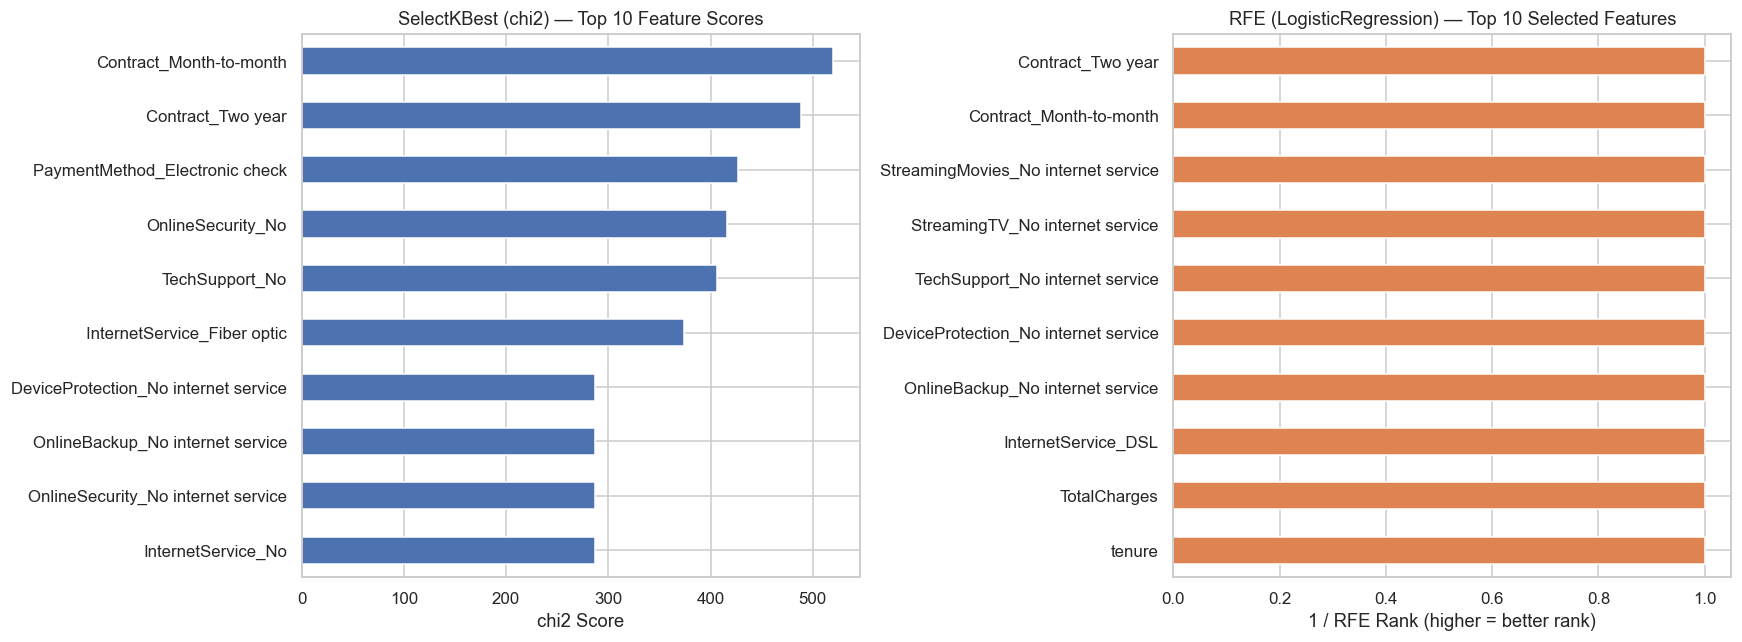

Saved: task2_selectkbest_rfe.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SelectKBest bar chart
skb_top10.sort_values().plot.barh(ax=axes[0], color='#4C72B0')
axes[0].set_title('SelectKBest (chi2) — Top 10 Feature Scores', fontsize=12)
axes[0].set_xlabel('chi2 Score')

# RFE ranking (use inverse of ranking for bar height)
rfe_ranks = pd.Series(rfe.ranking_, index=X_std_var.columns)
rfe_selected_ranks = rfe_ranks[rfe_top10].sort_values()
(1 / rfe_selected_ranks).sort_values().plot.barh(ax=axes[1], color='#DD8452')
axes[1].set_title('RFE (LogisticRegression) — Top 10 Selected Features', fontsize=12)
axes[1].set_xlabel('1 / RFE Rank (higher = better rank)')

plt.tight_layout()
plt.savefig('task2_selectkbest_rfe.png', bbox_inches='tight')
plt.show()
print('Saved: task2_selectkbest_rfe.png')

### Why Do the Selected Features Differ?

**SelectKBest with chi2** is a *filter method*: it ranks features independently of any model by measuring the statistical dependency between each feature and the target variable (using the chi-squared statistic). It favours features with high absolute co-variation with the target — in a churn dataset these tend to be high-magnitude features like `TotalCharges` and `MonthlyCharges`.

**RFE with LogisticRegression** is a *wrapper method*: it fits a model repeatedly, removing the weakest feature at each step based on coefficient magnitude. Because it considers the joint contribution of features inside a linear model, it can prefer a different mix — for example, contract type or tenure — that are individually less "statistically extreme" but are more useful when combined with the model's decision boundary.

The differences arise from three sources:
1. **Selection philosophy**: filter (univariate statistics) vs. wrapper (model-centric elimination)
2. **Feature interactions**: RFE captures how features work together; chi2 treats each feature in isolation
3. **Scale sensitivity**: chi2 can be dominated by high-variance continuous features; logistic regression coefficients reflect relative importance after scaling

---
## 4. LASSO for Feature Selection

In [14]:
# LASSO requires StandardScaler
X_lasso = X_scaled[kept_features].copy()

lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_lasso, y)

print(f'Best alpha (lambda) selected by LassoCV: {lasso_cv.alpha_:.6f}')

coef_series = pd.Series(lasso_cv.coef_, index=X_lasso.columns)
nonzero_coefs = coef_series[coef_series != 0].sort_values()

print(f'\nFeatures with non-zero coefficients: {len(nonzero_coefs)} / {len(coef_series)}')
print(nonzero_coefs.to_string())

Best alpha (lambda) selected by LassoCV: 0.000954

Features with non-zero coefficients: 19 / 45
TotalCharges                     -9.715647e-02
tenure                           -4.841089e-02
MultipleLines_No                 -4.361950e-02
PaperlessBilling_No              -4.294427e-02
Contract_One year                -2.885023e-02
Dependents_Yes                   -7.091634e-17
PaperlessBilling_Yes              3.253279e-16
DeviceProtection_No               1.966701e-03
SeniorCitizen                     1.651493e-02
Dependents_No                     1.782404e-02
OnlineBackup_No                   1.949327e-02
MonthlyCharges                    2.535739e-02
StreamingTV_Yes                   3.679136e-02
StreamingMovies_Yes               3.954634e-02
TechSupport_No                    5.251010e-02
OnlineSecurity_No                 5.263389e-02
PaymentMethod_Electronic check    7.083039e-02
Contract_Month-to-month           7.446849e-02
InternetService_Fiber optic       1.539511e-01


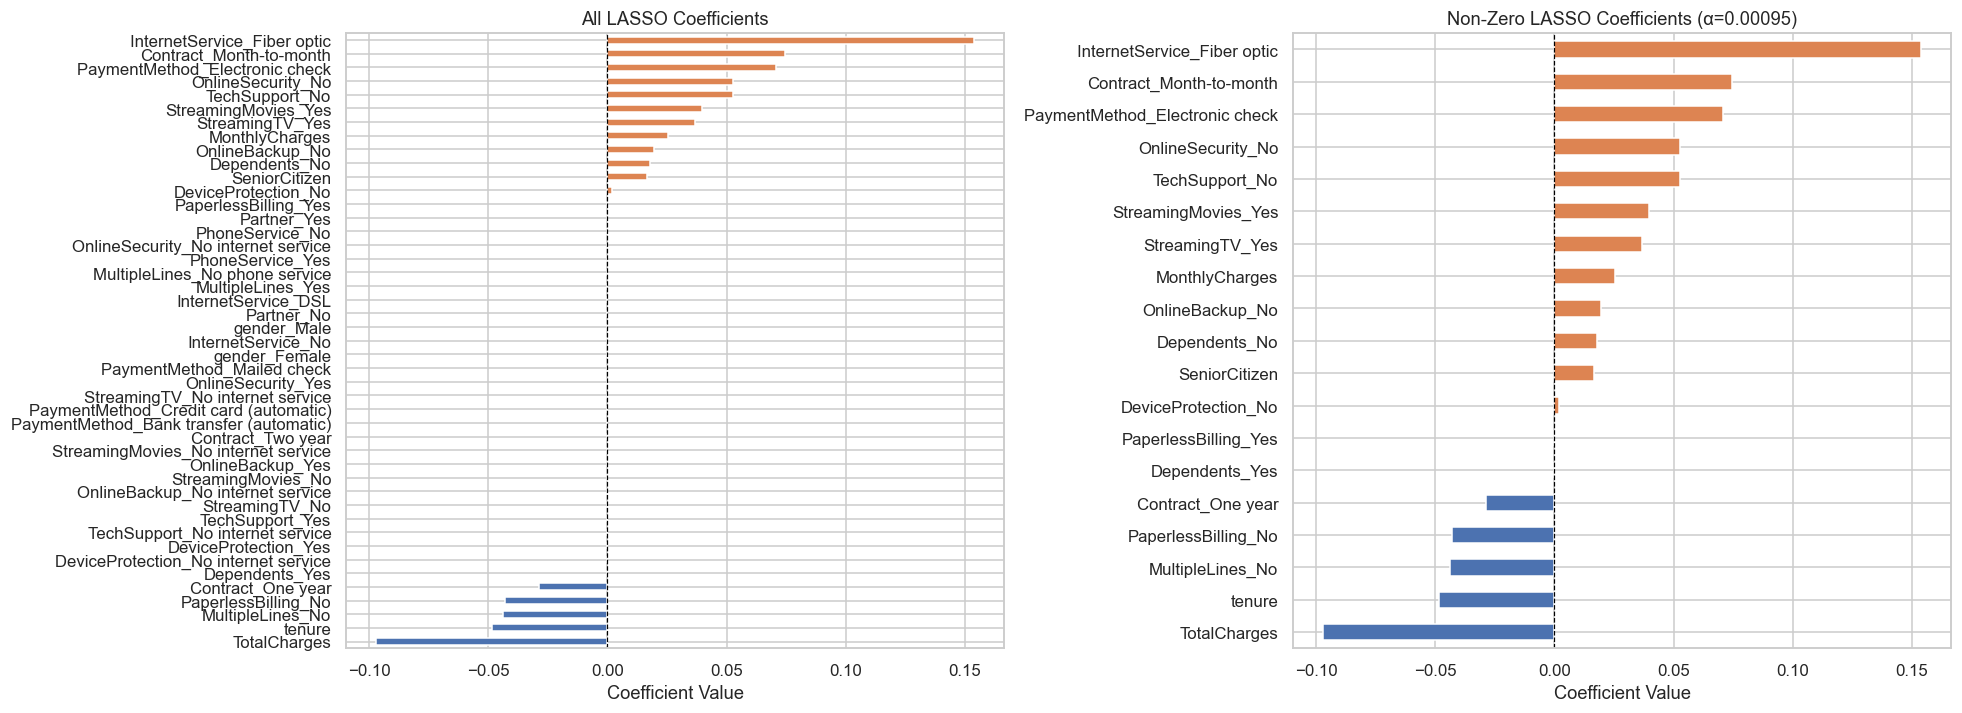

Saved: task2_lasso_coefficients.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(nonzero_coefs) * 0.35)))

# All coefficients sorted
coef_all = coef_series.sort_values()
colors_all = ['#DD8452' if v > 0 else '#4C72B0' for v in coef_all]
coef_all.plot.barh(ax=axes[0], color=colors_all)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('All LASSO Coefficients', fontsize=12)
axes[0].set_xlabel('Coefficient Value')

# Non-zero only
colors_nz = ['#DD8452' if v > 0 else '#4C72B0' for v in nonzero_coefs]
nonzero_coefs.plot.barh(ax=axes[1], color=colors_nz)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(f'Non-Zero LASSO Coefficients (α={lasso_cv.alpha_:.5f})', fontsize=12)
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('task2_lasso_coefficients.png', bbox_inches='tight')
plt.show()
print('Saved: task2_lasso_coefficients.png')

### How LASSO Handles Feature Correlation and Redundancy

LASSO (Least Absolute Shrinkage and Selection Operator) adds an **L1 penalty** (\(\lambda \sum |w_j|\)) to the loss function. This has a geometric property that drives some coefficients to exactly zero, effectively removing those features from the model.

When features are **correlated** (e.g. `MonthlyCharges` and `TotalCharges` — total is approximately monthly × tenure), LASSO tends to keep one and shrink the other to zero, performing automatic feature selection. The choice of which correlated feature survives is somewhat arbitrary but consistent given the same data.

When features are **redundant** (near-duplicate information), LASSO achieves sparsity without losing predictive accuracy: the retained coefficient absorbs the combined signal, and the zeroed-out coefficients indicate those features did not add independent explanatory power.

Cross-validation (`LassoCV`) automatically selects the optimal regularisation strength \(\alpha\), balancing the trade-off between model fit and sparsity.

---
## 5. Final Model Pipeline

In [16]:
# Split original (pre-scaled) encoded data for a fair pipeline evaluation
X_raw = df_encoded.drop(columns=['Churn'])
y_raw = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print('Train size:', X_train.shape, '  Test size:', X_test.shape)

Train size: (5634, 45)   Test size: (1409, 45)


In [17]:
# Identify numeric and binary (one-hot) columns in raw encoded X
raw_num_cols = [c for c in X_raw.columns
                if X_raw[c].dtype in ['float64', 'int64'] and X_raw[c].nunique() > 2]
raw_bin_cols = [c for c in X_raw.columns if c not in raw_num_cols]

# Preprocessor: impute + scale numeric, passthrough binary dummies
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, raw_num_cols),
    ('bin', binary_transformer, raw_bin_cols)
])

# Full pipeline: Preprocessing -> Feature Selection (LassoCV) -> LogisticRegression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        LassoCV(cv=5, max_iter=10000, random_state=42)
    )),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

pipeline.fit(X_train, y_train)
print('Pipeline trained successfully.')

Pipeline trained successfully.


In [18]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
mae      = mean_absolute_error(y_test, y_pred)

print('=== Final Model Evaluation ===')
print(f'Accuracy : {accuracy:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')

=== Final Model Evaluation ===
Accuracy : 0.8048
ROC-AUC  : 0.8427
RMSE     : 0.4418
MAE      : 0.1952


In [19]:
# Features selected by SelectFromModel(LassoCV)
sfm = pipeline.named_steps['feature_selection']
prep = pipeline.named_steps['preprocessor']
feature_names_out = raw_num_cols + raw_bin_cols
selected_mask = sfm.get_support()
selected_pipeline_features = [f for f, s in zip(feature_names_out, selected_mask) if s]

print(f'Features selected by pipeline SelectFromModel: {len(selected_pipeline_features)}')
for f in selected_pipeline_features:
    print(' ', f)

Features selected by pipeline SelectFromModel: 19
  tenure
  MonthlyCharges
  TotalCharges
  SeniorCitizen
  Dependents_No
  MultipleLines_No
  MultipleLines_Yes
  InternetService_Fiber optic
  OnlineSecurity_No
  OnlineBackup_No
  DeviceProtection_No
  TechSupport_No
  StreamingTV_Yes
  StreamingMovies_Yes
  Contract_Month-to-month
  Contract_One year
  PaperlessBilling_No
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check


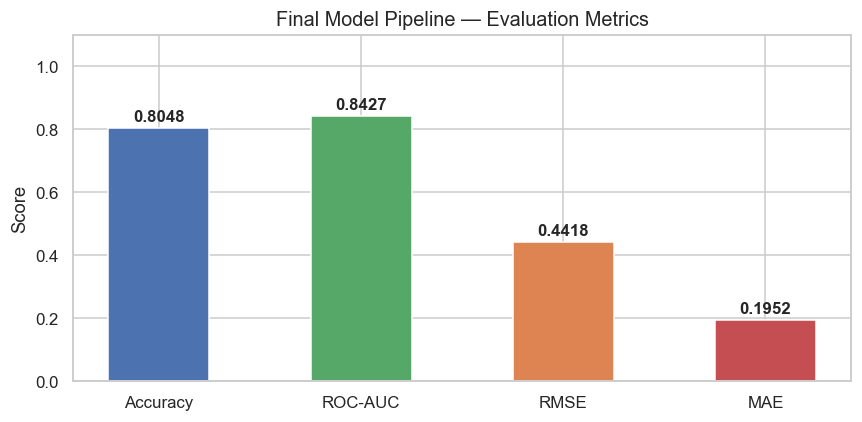

Saved: task2_model_metrics.png


In [20]:
# Visualise evaluation metrics
metrics = {'Accuracy': accuracy, 'ROC-AUC': roc_auc, 'RMSE': rmse, 'MAE': mae}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'], edgecolor='white', width=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Final Model Pipeline — Evaluation Metrics', fontsize=13)
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('task2_model_metrics.png', bbox_inches='tight')
plt.show()
print('Saved: task2_model_metrics.png')

---
## 6. Discussion Questions

### Q1. Why is it important to perform both encoding and scaling before applying LASSO or PCA in datasets with mixed data types?

Datasets like Telco Churn contain a mix of **categorical** and **continuous** features. Before LASSO or PCA can be applied, two transformations are necessary:

1. **Encoding** — Machine learning algorithms (and the linear algebra inside PCA and LASSO) require numeric inputs. Categorical variables such as `Contract`, `InternetService`, or `PaymentMethod` must be converted to numbers via one-hot encoding or label encoding; otherwise, the model cannot interpret them at all.

2. **Scaling** — LASSO penalises coefficient magnitude with an L1 norm. If features are on different scales (e.g. `tenure` ranges 0–72 while a binary dummy is 0/1), the penalty disproportionately shrinks large-scale features, introducing bias in which features are zeroed out — not because they are less important, but simply because their raw values are smaller. Similarly, PCA is a variance-maximisation procedure: unscaled high-magnitude features will dominate the first principal components regardless of their true informational value. Standardising to zero mean and unit variance ensures that every feature competes on equal footing.

Skipping either step leads to systematically biased feature selection and misleading dimensionality reduction.

---

### Q2. How do embedded methods like LASSO differ from filter and wrapper feature selection methods?

| Aspect | Filter Methods (e.g. chi2, Variance Threshold) | Wrapper Methods (e.g. RFE) | Embedded Methods (e.g. LASSO) |
|---|---|---|---|
| **Selection mechanism** | Statistical test on each feature independently | Model retrained iteratively, features dropped one by one | Feature importance derived during model training itself |
| **Model awareness** | Model-agnostic — no model is used | Dependent on the chosen estimator | Intrinsic to the model (regularisation penalty) |
| **Feature interactions** | Not captured | Partially captured (through model performance) | Captured implicitly via coefficient shrinkage |
| **Computation cost** | Very low | High (re-trains model N times) | Medium (single model with cross-validation) |
| **Risk of overfitting** | Low | Higher (selection process may overfit to training set) | Lower (regularisation inherently resists overfitting) |
| **Handles correlation** | No — can select redundant correlated features | Partial | Yes — tends to keep one of a correlated group |

**Key distinction for LASSO:** The regularisation parameter \(\alpha\) simultaneously controls model complexity and feature selection. Rather than treating selection as a pre-processing step separate from model training, LASSO integrates both objectives into a single optimisation, producing a sparse and generalisable model in one pass. This makes it more efficient and often more principled than sequential wrapper methods, at the cost of being restricted to models that support L1 regularisation (linear models, certain tree models with leaf penalties, etc.).